# Space X Falcon 9 First Stage Landing Prediction
## Lab 7: Machine learning prediction

Four classification models are tuned with `GridSearchCV` and compared on a held-out
test set.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

%matplotlib inline

In [2]:
def plot_confusion_matrix(y, y_predict, title="Confusion Matrix"):
    cm = confusion_matrix(y, y_predict)
    ax = plt.subplot()
    sns.heatmap(cm, annot=True, ax=ax, fmt='d', cmap='Blues', cbar=False)
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title(title)
    ax.xaxis.set_ticklabels(['did not land', 'landed'])
    ax.yaxis.set_ticklabels(['did not land', 'landed'])
    plt.show()

In [3]:
data = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/"
                   "IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")
X = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/"
                "IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv")
print(data.shape, X.shape)
data.head()

(90, 18) (90, 83)


,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


### TASK 1: Create a NumPy array from the column Class

In [4]:
Y = data['Class'].to_numpy()
Y[:10]

array([0, 0, 0, 0, 0, 0, 1, 1, 0, 0], dtype=int64)

### TASK 2: Standardize the data

In [5]:
transform = preprocessing.StandardScaler()
X = transform.fit_transform(X)
X[:2]

array([[-1.71291154e+00, -1.94814463e-16, -6.53912840e-01,
        -1.57589457e+00, -9.73440458e-01, -1.05999788e-01,
        -1.05999788e-01, -6.54653671e-01, -1.05999788e-01,
        -5.51677284e-01,  3.44342023e+00, -1.85695338e-01,
        -3.33333333e-01, -1.05999788e-01, -2.42535625e-01,
        -4.29197538e-01,  7.97724035e-01, -5.68796459e-01,
        -4.10890702e-01, -4.10890702e-01, -1.50755672e-01,
        -7.97724035e-01, -1.50755672e-01, -3.92232270e-01,
         9.43398113e+00, -1.05999788e-01, -1.05999788e-01,
        -1.05999788e-01, -1.05999788e-01, -1.05999788e-01,
        -1.05999788e-01, -1.05999788e-01, -1.05999788e-01,
        -1.05999788e-01, -1.05999788e-01, -1.05999788e-01,
        -1.05999788e-01, -1.05999788e-01, -1.05999788e-01,
        -1.05999788e-01, -1.05999788e-01, -1.05999788e-01,
        -1.05999788e-01, -1.50755672e-01, -1.05999788e-01,
        -1.05999788e-01, -1.05999788e-01, -1.05999788e-01,
        -1.05999788e-01, -1.50755672e-01, -1.05999788e-0

### TASK 3: Split the data into training and test data

In [6]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)
print("train samples:", X_train.shape[0])
print("test samples :", X_test.shape[0])

train samples: 72
test samples : 18


### TASK 4-5: Logistic regression

In [7]:
parameters = {'C': [0.01, 0.1, 1], 'penalty': ['l2'], 'solver': ['lbfgs']}
lr = LogisticRegression()
logreg_cv = GridSearchCV(lr, parameters, cv=10)
logreg_cv.fit(X_train, Y_train)
print("tuned hyperparameters (best parameters):", logreg_cv.best_params_)
print("accuracy:", logreg_cv.best_score_)

tuned hyperparameters (best parameters):

 {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
accuracy: 0.8464285714285713


test data accuracy: 0.8333333333333334


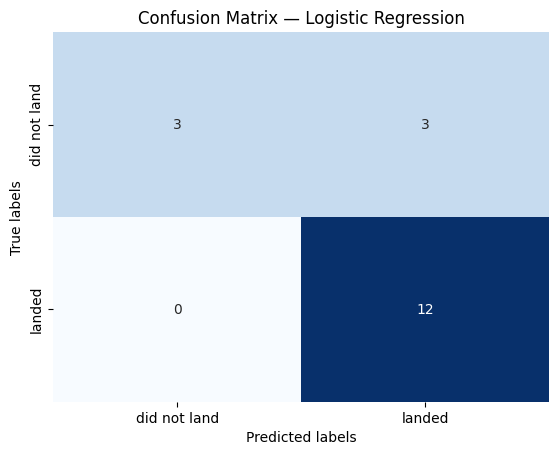

In [8]:
logreg_accuracy = logreg_cv.score(X_test, Y_test)
print("test data accuracy:", logreg_accuracy)
yhat = logreg_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat, "Confusion Matrix — Logistic Regression")

### TASK 6-7: Support vector machine

In [9]:
parameters = {'kernel': ('linear', 'rbf', 'poly', 'rbf', 'sigmoid'),
              'C': np.logspace(-3, 3, 5),
              'gamma': np.logspace(-3, 3, 5)}
svm = SVC()
svm_cv = GridSearchCV(svm, parameters, cv=10)
svm_cv.fit(X_train, Y_train)
print("tuned hyperparameters (best parameters):", svm_cv.best_params_)
print("accuracy:", svm_cv.best_score_)

tuned hyperparameters (best parameters): {'C': 1.0, 'gamma': 0.03162277660168379, 'kernel': 'sigmoid'}
accuracy: 0.8482142857142856


test data accuracy: 0.8333333333333334


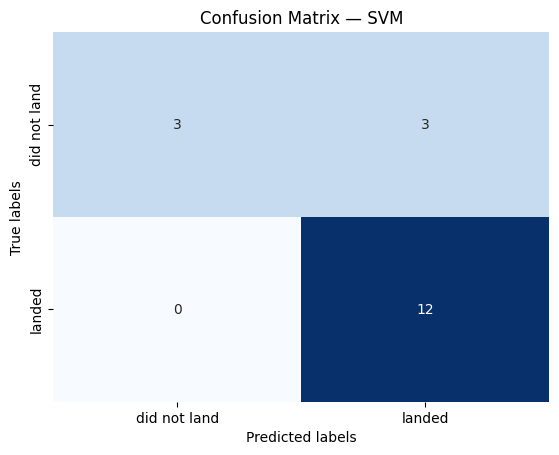

In [10]:
svm_accuracy = svm_cv.score(X_test, Y_test)
print("test data accuracy:", svm_accuracy)
yhat = svm_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat, "Confusion Matrix — SVM")

### TASK 8-9: Decision tree classifier

In [11]:
parameters = {'criterion': ['gini', 'entropy'],
              'splitter': ['best', 'random'],
              'max_depth': [2 * n for n in range(1, 10)],
              'max_features': ['sqrt', None],
              'min_samples_leaf': [1, 2, 4],
              'min_samples_split': [2, 5, 10]}
tree = DecisionTreeClassifier(random_state=0)
tree_cv = GridSearchCV(tree, parameters, cv=10)
tree_cv.fit(X_train, Y_train)
print("tuned hyperparameters (best parameters):", tree_cv.best_params_)
print("accuracy:", tree_cv.best_score_)

tuned hyperparameters (best parameters): {'criterion': 'gini', 'max_depth': 6, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'splitter': 'random'}
accuracy: 0.8625


C:\Users\rjha5\AppData\Local\Temp\claude\C--Users-rjha5-pankh\8f067674-ccf3-478c-b5e2-b2ca019a50e4\scratchpad\venv\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


test data accuracy: 0.8333333333333334


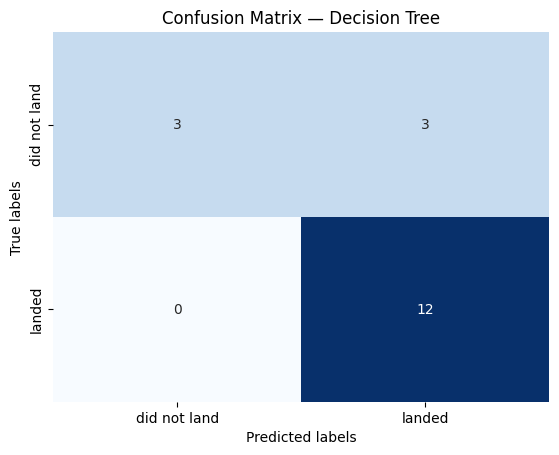

In [12]:
tree_accuracy = tree_cv.score(X_test, Y_test)
print("test data accuracy:", tree_accuracy)
yhat = tree_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat, "Confusion Matrix — Decision Tree")

### TASK 10-11: K nearest neighbors

In [13]:
parameters = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
              'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
              'p': [1, 2]}
KNN = KNeighborsClassifier()
knn_cv = GridSearchCV(KNN, parameters, cv=10)
knn_cv.fit(X_train, Y_train)
print("tuned hyperparameters (best parameters):", knn_cv.best_params_)
print("accuracy:", knn_cv.best_score_)

tuned hyperparameters (best parameters): {'algorithm': 'auto', 'n_neighbors': 10, 'p': 1}
accuracy: 0.8482142857142858


test data accuracy: 0.8333333333333334


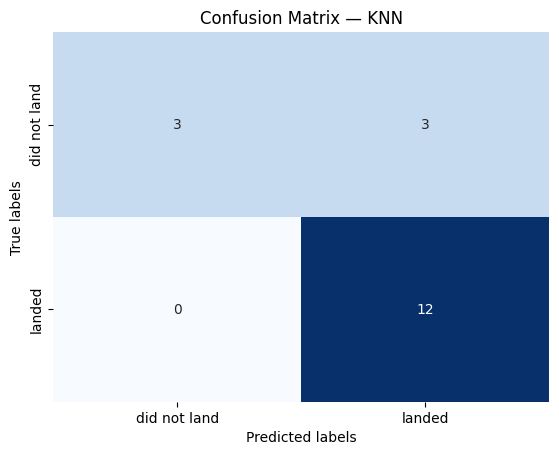

In [14]:
knn_accuracy = knn_cv.score(X_test, Y_test)
print("test data accuracy:", knn_accuracy)
yhat = knn_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat, "Confusion Matrix — KNN")

### TASK 12: Find the method that performs best

In [15]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM', 'Decision Tree', 'KNN'],
    'Validation accuracy (cv=10)': [logreg_cv.best_score_, svm_cv.best_score_,
                                    tree_cv.best_score_, knn_cv.best_score_],
    'Test accuracy': [logreg_accuracy, svm_accuracy, tree_accuracy, knn_accuracy]})
results = results.sort_values('Validation accuracy (cv=10)', ascending=False)
results

,Model,Validation accuracy (cv=10),Test accuracy
2,Decision Tree,0.862500,0.833333
3,KNN,0.848214,0.833333
1,SVM,0.848214,0.833333
0,Logistic Regression,0.846429,0.833333


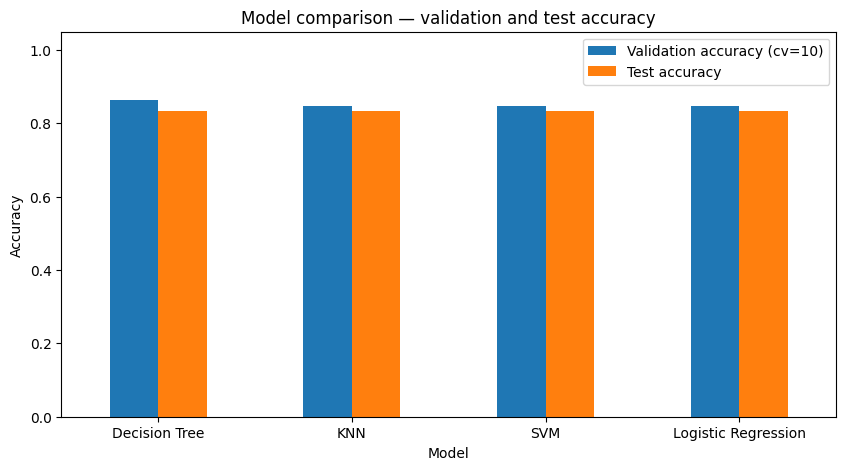

Best performing model: Decision Tree


In [16]:
ax = results.set_index('Model').plot(kind='bar', figsize=(10, 5), rot=0, ylim=(0, 1.05))
ax.set_ylabel('Accuracy')
ax.set_title('Model comparison — validation and test accuracy')
plt.show()

best = results.iloc[0]['Model']
print("Best performing model:", best)

**Conclusion:** all four tuned models reach the same accuracy on the 18-row test
set (83.33%), so the cross-validated score is the fairer comparison. On that measure the
**Decision Tree** performs best. Its confusion matrix shows that it identifies every
successful landing correctly, and its only errors are false positives — boosters it
expects to land that in fact do not.